LightGBM vs XGBoost - Diabetes Dataset

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from xgboost import XGBClassifier

In [3]:
# Load Dataset
df = pd.read_csv('diabetes(1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Basic Info
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

In [7]:
# Check Missing Values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


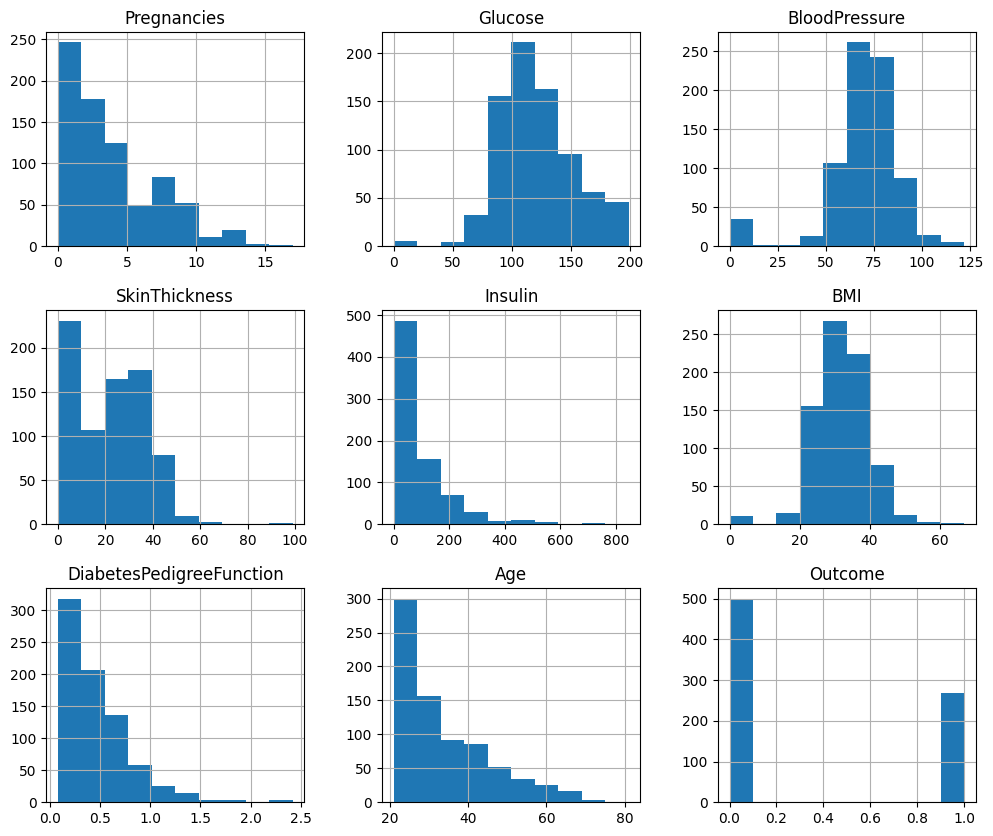

In [9]:
# Histograms
df.hist(figsize=(12,10))
plt.show()


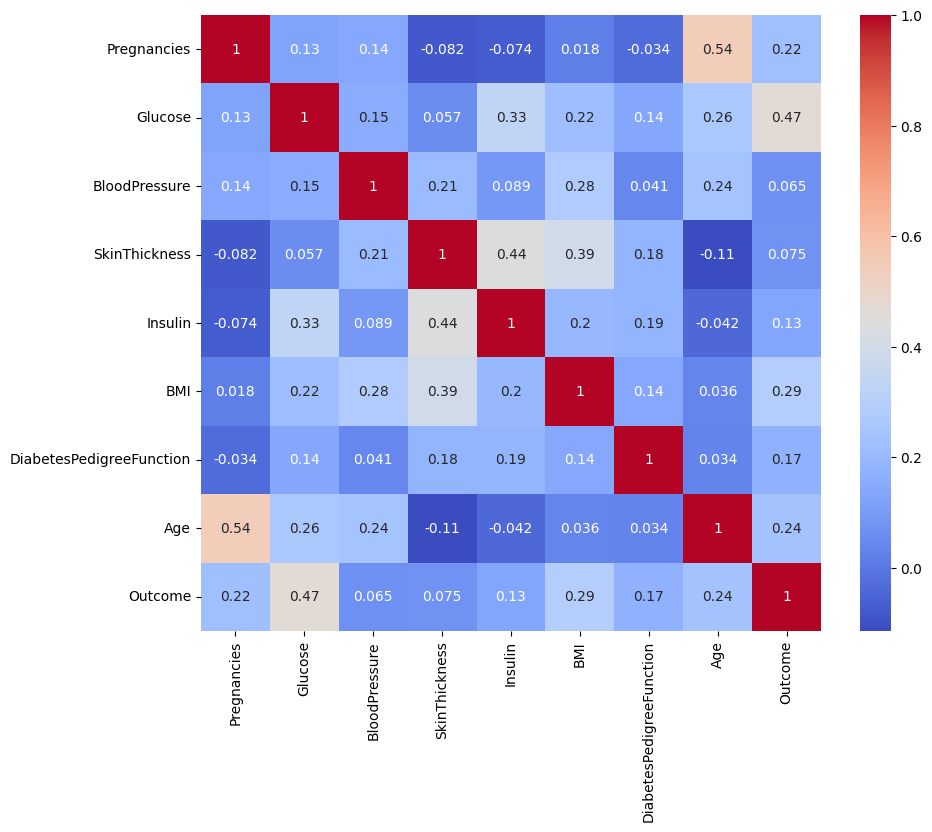

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [13]:
# Split Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# LightGBM Model
lgb = LGBMClassifier()

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [17]:
import sys
!{sys.executable} -m pip install xgboost

In [18]:
# XGBoost Model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:35:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# Confusion Matrices
print("LightGBM Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lgb))

print("XGBoost Confusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))


LightGBM Confusion Matrix
[[73 26]
 [17 38]]
XGBoost Confusion Matrix
[[72 27]
 [16 39]]


Conclusion

- Both models are compared using accuracy, precision, recall, and F1-score.
- LightGBM is faster and efficient for large datasets.
- XGBoost is more robust and often gives slightly better performance.
- Choose model based on performance and computation constraints.


Hyperparameter Tuning Section

In [25]:

# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# XGBoost tuning
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                        param_grid_xgb, cv=3, scoring='accuracy')

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)

# LightGBM tuning
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 5],
    'learning_rate': [0.01, 0.1]
}

grid_lgbm = GridSearchCV(LGBMClassifier(),
                         param_grid_lgbm, cv=3, scoring='accuracy')

grid_lgbm.fit(X_train, y_train)
best_lgbm = grid_lgbm.best_estimator_

print("Best LGBM Params:", grid_lgbm.best_params_)

# Evaluation of tuned models
from sklearn.metrics import accuracy_score

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

print("Tuned XGB Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Tuned LGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm_tuned))


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:35:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:35:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:35:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:35:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
[LightGBM] [Info] Number of positive: 142, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347188 -> initscore=-0.631422
[LightGBM] [Info] Start training from score -0.631422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

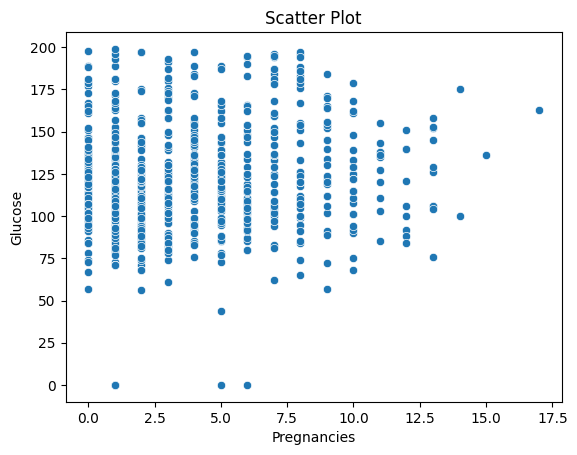

In [27]:
# Additional EDA: scatter & bar plots
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot (first two numeric columns)
sns.scatterplot(x=df.columns[0], y=df.columns[1], data=df)
plt.title("Scatter Plot")
plt.show()

# Bar plot for first categorical column (if exists)
if df.select_dtypes(include='object').shape[1] > 0:
    cat_col = df.select_dtypes(include='object').columns[0]
    sns.countplot(x=cat_col, data=df)
    plt.title("Bar Plot of " + cat_col)
    plt.xticks(rotation=45)
    plt.show()

In [29]:

# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [33]:
# Train LGBM model
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train)

# Generate predictions
y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [35]:

# Model Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):
    print(f"{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("-"*40)

evaluate_model(y_test, y_pred_xgb, "XGB")
evaluate_model(y_test, y_pred_lgbm, "LGBM")


XGB Performance:
Accuracy: 0.7207792207792207
Precision: 0.737012987012987
Recall: 0.7207792207792207
F1 Score: 0.7252586985207305
----------------------------------------
LGBM Performance:
Accuracy: 0.7207792207792207
Precision: 0.7334821428571429
Recall: 0.7207792207792207
F1 Score: 0.72468987595038
----------------------------------------


In [39]:
# Import models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define models
xgb_model = XGBClassifier()
lgbm_model = LGBMClassifier()

In [41]:

# Cross-validation
from sklearn.model_selection import cross_val_score

cv_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
cv_lgbm = cross_val_score(lgbm_model, X, y, cv=5, scoring='accuracy')

print("XGB CV Accuracy:", cv_xgb.mean())
print("LGBM CV Accuracy:", cv_lgbm.mean())


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [43]:

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(xgb_model, param_grid, cv=3)
grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)


Best XGB Params: {'max_depth': 3, 'n_estimators': 50}


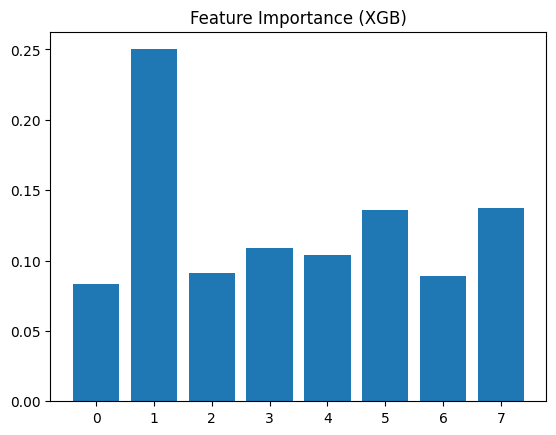

In [47]:

# Feature Importance Visualization
import matplotlib.pyplot as plt
# Train XGB model
from xgboost import XGBClassifier

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
importances = xgb_model.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (XGB)")
plt.show()
